
# **Лабораторна робота №3**
##### Варіант №8

### **Тема:** Розв’язування систем нелінійних рівнянь

**Мета:** ознайомлення студентів з чисельними методами розв’язування нелінійних
систем; набуття практичних навичок розв’язання таких задач (у тому числі - з
використанням комп’ютера).

Виконали:
1. Михайлюк Віталій
2. Лісовий Максим
3. Андрусик Вікторія
4. Оленич Максим

Лідер команди: **Михайлюк Віталій**

#### **Завдання**

1. Опрацювати теоретичний матеріал
2. Знайти наближений розв’язок заданої нелінійної системи з точністю до
10<sup>-3</sup>

- Методом Ньютона;
- Методом простої ітерації;
- Методом Зейделя.

**Надана система нелінійних рівнянь**

$$
\begin{cases}
\cos(2x - 1) + y = 0,8 \\
x - \cos y = 2
\end{cases}
$$


### **Програмна реалізація**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, List, Tuple
import math 

In [2]:
def phi_1(x: float, y: float) -> float:
    return 2.0 + math.cos(y)

def phi_2(x: float, y: float) -> float:
    return 0.8 - math.cos(2.0 * x - 1.0)

def variant8_phi(vars: List[float]) -> List[float]:
    x, y = vars
    # Перетворення рівнянь
    # 1) x - cos(y) = 2          =>  x = 2 + cos(y)
    # 2) cos(2x - 1) + y = 0.8   =>  y = 0.8 - cos(2x - 1)
    
    new_x = 2.0 + math.cos(y)
    new_y = 0.8 - math.cos(2.0 * x - 1.0)
    
    return [new_x, new_y]


**Метод Ньютона:**

In [3]:
def newton_system(
    func: Callable[[np.ndarray], np.ndarray],
    jacobian: Callable[[np.ndarray], np.ndarray],
    x0: np.ndarray,
    # точність 0.001 має бути
    tol: float = 1e-3,
    max_iter: int = 100
) -> Tuple[np.ndarray, int]:
    """
    Метод Ньютона для розв'язання системи нелінійних рівнянь.
    Алгоритм ітеративно знаходить вектор x, для якого F(x) = 0, використовуючи
    формулу x_{k+1} = x_k - J(x_k)^{-1} * F(x_k). Для обчислювальної стабільності
    замість обернення матриці розв'язується СЛАР: J(x_k) * dx = -F(x_k),
    після чого вектор наближень оновлюється: x_{k+1} = x_k + dx.
    """
    x = np.array(x0, dtype=float)

    for i in range(max_iter):
        f_val = func(x)

        # Перевірка умови збіжності за нев'язкою
        if np.linalg.norm(f_val, ord=np.inf) < tol:
            return x, i

        # Обчислення матриці Якобі та приросту dx
        J = jacobian(x)
        dx = np.linalg.solve(J, -f_val)
        x = x + dx

        # Перевірка умови збіжності за приростом аргументу
        if np.linalg.norm(dx, ord=np.inf) < tol:
            return x, i + 1  # * повертай також масив похибок для ітерацій, це потрібно для візуалізації збіжності

    raise ValueError("Метод Ньютона не зійшовся за задану кількість ітерацій")


**Метод Зейделя**

In [4]:
def seidel_nonlinear(
    phi1: Callable[[float, float], float],
    phi2: Callable[[float, float], float],
    x0: float,
    y0: float,
    epsilon: float = 1e-3,
    max_iter: int = 1000
) -> Tuple[float, float, List[float]]:
    """Розв'язує систему двох нелінійних рівнянь методом Зейделя."""
    x_curr, y_curr = x0, y0
    errors: List[float] = []

    for _ in range(max_iter):
        x_prev, y_prev = x_curr, y_curr

        # Крок Зейделя: координата y обчислюється з новим значенням x
        x_curr = phi1(x_prev, y_prev)
        y_curr = phi2(x_curr, y_prev)

        # Оцінка похибки між сусідніми наближеннями
        delta = max(abs(x_curr - x_prev), abs(y_curr - y_prev))
        errors.append(delta)

        if delta <= epsilon:
            return x_curr, y_curr, errors

    raise RuntimeError("Метод Зейделя не зійшовся за максимальну кількість ітерацій.")

**Метод простої ітерації**

In [5]:
def simple_iteration_system(
    phi: Callable[[List[float]], List[float]],
    x0: List[float],
    epsilon: float = 0.001,
    max_iter: int = 1000
) -> Tuple[List[float], int]:
    """
    Реалізує метод простої ітерації для розв'язання систем нелінійних рівнянь
    
    Математична основа:
    Початкова система рівнянь F(x, y) = 0 перетворюється до еквівалентного 
    ітераційного вигляду x = Phi_1(x, y) та y = Phi_2(x, y)
    Починаючи з початкового наближення x0, кожне наступне наближення 
    обчислюється як x_{k+1} = Phi(x_k)
    Процес зупиняється, коли максимальна різниця між змінними 
    на сусідніх ітераціях стає меншою за задану точність epsilon.
    
    :param phi: Функція, що реалізує ітераційне відображення Phi(x)
    :param x0: Початкове наближення (список)
    :param epsilon: Задана точність
    :param max_iter: Максимальна кількість ітерацій
    :return: Кортеж (список знайдених коренів, кількість витрачених ітерацій)
    """
    
    # Валідація вхідних параметрів
    if epsilon <= 0:
        raise ValueError("Точність epsilon має бути строго більшою за нуль.")
    if max_iter <= 0:
        raise ValueError("Максимальна кількість ітерацій має бути додатнім цілим числом.")
    if not isinstance(x0, list) or len(x0) == 0:
        raise ValueError("Початкове наближення x0 має бути непорожнім списком.")
        
    x_prev = np.array(x0, dtype=float)
    
    for iteration in range(1, max_iter + 1):
        try:
            x_new = np.array(phi(x_prev.tolist()), dtype=float)
        except Exception as e:
            raise RuntimeError(f"Помилка обчислення функції Phi на ітерації {iteration}: {e}")
        
        # Перевірка умови зупинки
        max_diff = np.linalg.norm(x_new - x_prev, ord=np.inf)
        
        if max_diff < epsilon:
            return x_new.tolist(), iteration
            
        x_prev = x_new.copy()
        
    raise RuntimeError(f"Метод не зійшовся за {max_iter} ітерацій.")

**Виведення методів**

In [ ]:
if __name__ == "__main__":
    # Тестова система:
    # 1) x1 + x2 - 3 = 0
    # 2) x1^2 + x2^2 - 5 = 0
    def system_equations(x: np.ndarray) -> np.ndarray:
        return np.array([
            x[0] + x[1] - 3.0,
            x[0] ** 2 + x[1] ** 2 - 5.0
        ])

    def system_jacobian(x: np.ndarray) -> np.ndarray:
        return np.array([
            [1.0, 1.0],
            [2.0 * x[0], 2.0 * x[1]]
        ])

    print("Завдання №1: Метод Ньютона")
    print("---------------------------------------------")
    # Пошук першого розв'язку (1, 2)
    initial_guess_1 = np.array([0.0, 5.0])
    solution_1, iterations_1 = newton_system(system_equations, system_jacobian, initial_guess_1)
    print(f"Корінь 1: {solution_1}")
    print(f"Кількість ітерацій: {iterations_1}\n")
    # Пошук другого розв'язку (2, 1)
    initial_guess_2 = np.array([5.0, 0.0])
    solution_2, iterations_2 = newton_system(system_equations, system_jacobian, initial_guess_2)
    print(f"Корінь 2: {solution_2}")
    print(f"Кількість ітерацій: {iterations_2}")

    # Початкове наближення
    # x = 2 + cos(y) -> cos() дає від -1 до 1, тому x в районі 2.
    # y = 0.8 - cos(...) -> y в районі 1.
    initial_guess = [2.0, 1.0] 
    
    try:
        solution, iters = simple_iteration_system(variant8_phi, initial_guess, epsilon=0.001)
        print(f"Знайдені корені: x = {solution[0]:.5f}, y = {solution[1]:.5f}")
        print(f"Кількість ітерацій: {iters}")
    except Exception as e:
        print("Помилка:", e)

x_sol, y_sol, errors = seidel_nonlinear(phi_1, phi_2, x0=2.0, y0=0.0, epsilon=1e-3)

print(f"Розв'язок: x* ≈ {x_sol:.4f}, y* ≈ {y_sol:.4f}")
print(f"Кількість ітерацій: {len(errors)}")

def variant8_phi(vars: List[float]) -> List[float]:
    x, y = vars
    # Перетворення рівнянь
    # 1) x - cos(y) = 2          =>  x = 2 + cos(y)
    # 2) cos(2x - 1) + y = 0.8   =>  y = 0.8 - cos(2x - 1)
    
    new_x = 2.0 + math.cos(y)
    new_y = 0.8 - math.cos(2.0 * x - 1.0)
    
    return [new_x, new_y]



Завдання №1
---------------------------------------------
Корінь 1: [0.99998474 2.00001526]
Кількість ітерацій: 5

Корінь 2: [2.00001526 0.99998474]
Кількість ітерацій: 5
Знайдені корені: x = 1.85978, y = 1.71236
Кількість ітерацій: 52
Розв'язок: x* ≈ 1.8590, y* ≈ 1.7116
Кількість ітерацій: 32


**Візуалізація**

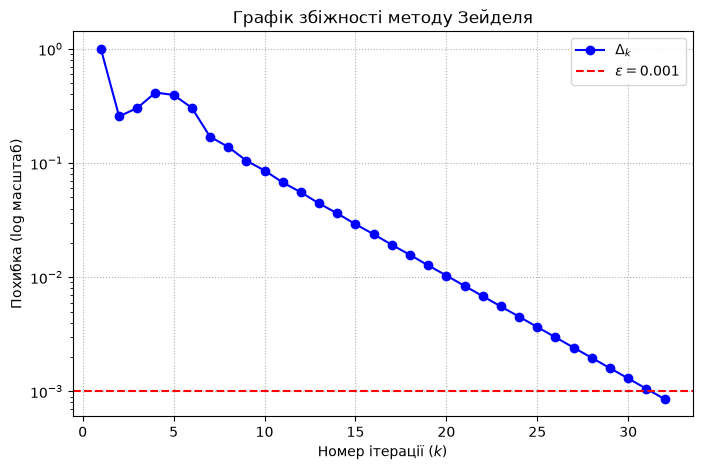

In [7]:
def plot_convergence(errors: List[float], epsilon: float = 1e-3) -> None:
    """Будує графік залежності похибки від номера ітерації."""
    plt.figure(figsize=(8, 5))
    # загорнути в цикл
    plt.plot(range(1, len(errors) + 1), errors, marker='o', linestyle='-', color='b', label=r'$\Delta_k$')
    plt.axhline(y=epsilon, color='r', linestyle='--', label=f'$\\varepsilon = {epsilon}$')

    plt.yscale('log')
    plt.xlabel('Номер ітерації ($k$)')
    plt.ylabel('Похибка (log масштаб)')
    plt.title('Графік збіжності методу Зейделя')
    plt.grid(True, linestyle=':')
    plt.legend()
    plt.show()

plot_convergence(errors, epsilon=1e-3)
